In [1]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('Data/vehicles.csv')

In [2]:
# Display the first few rows of the dataframe
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [3]:
# Display the information(non null count, Dtype) about the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

In [4]:
# Check for missing values
df.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

In [5]:
# Display the summary statistics of the dataframe
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


Text(0, 0.5, 'Frequency')

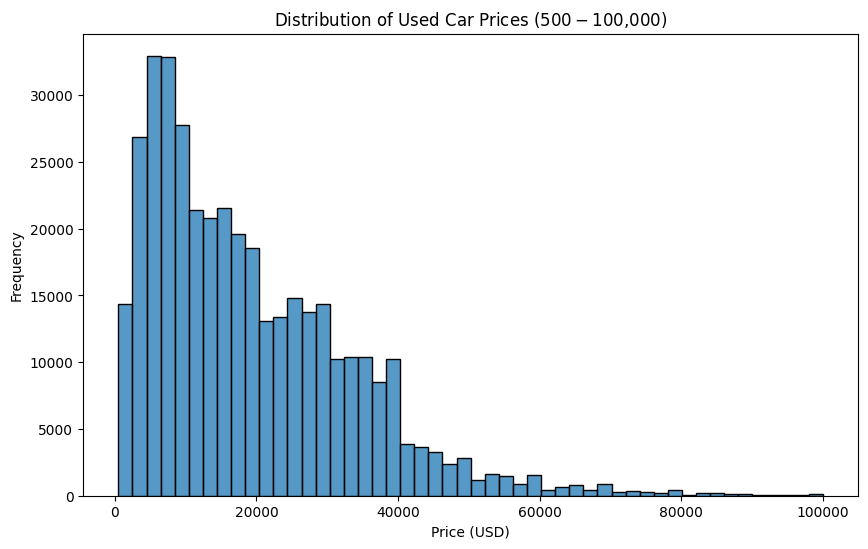

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of the price ($500 ~ $100,000)
filtered_df = df[(df['price'] >= 500) & (df['price'] <= 100000)]

plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['price'], bins=50, edgecolor='black')

plt.title('Distribution of Used Car Prices ($500 - $100,000)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')

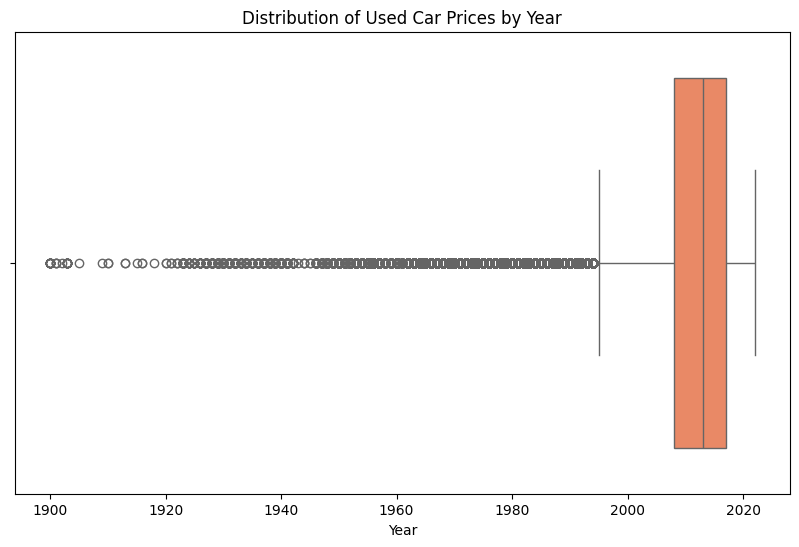

In [7]:
# Plot the distribution of the year (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='year', color='coral')
plt.title('Distribution of Used Car Prices by Year')
plt.xlabel('Year')
plt.show()

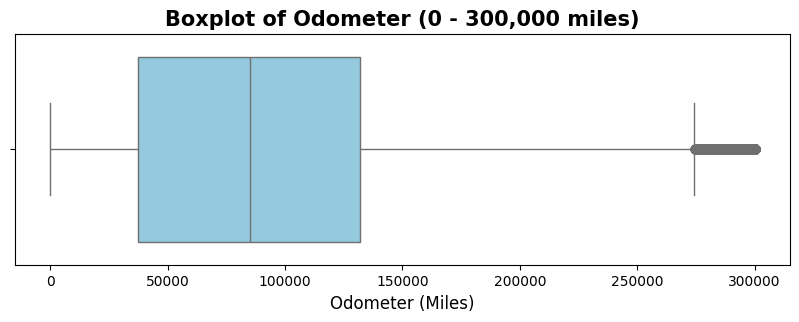

In [21]:
# 300,000 miles is the realistic upper limit for odometer
filtered_df = df[df['odometer'] <= 300000]

# display the boxplot of the odometer
plt.figure(figsize=(10, 3))
sns.boxplot(data=filtered_df, x='odometer', color='skyblue')

plt.title('Boxplot of Odometer (0 - 300,000 miles)', fontsize=15, fontweight='bold')
plt.xlabel('Odometer (Miles)', fontsize=12)

plt.show()

In [8]:
def show_countplot(df, column):
    # Fill the missing values with 'N/A' to view the distribution of the column
    df_clean = df.copy()
    df_clean[column] = df_clean[column].fillna('N/A')

    # Plot the distribution of the column (countplot)
    plt.figure(figsize=(10, 10))
    # palette='viridis' is a color palette for the plot
    sns.countplot(y=column, data=df_clean, hue=column, order=df_clean[column].value_counts().index, palette='viridis')
    plt.title('Distribution of Used Car ' + column)
    plt.xlabel(column)
    plt.show()

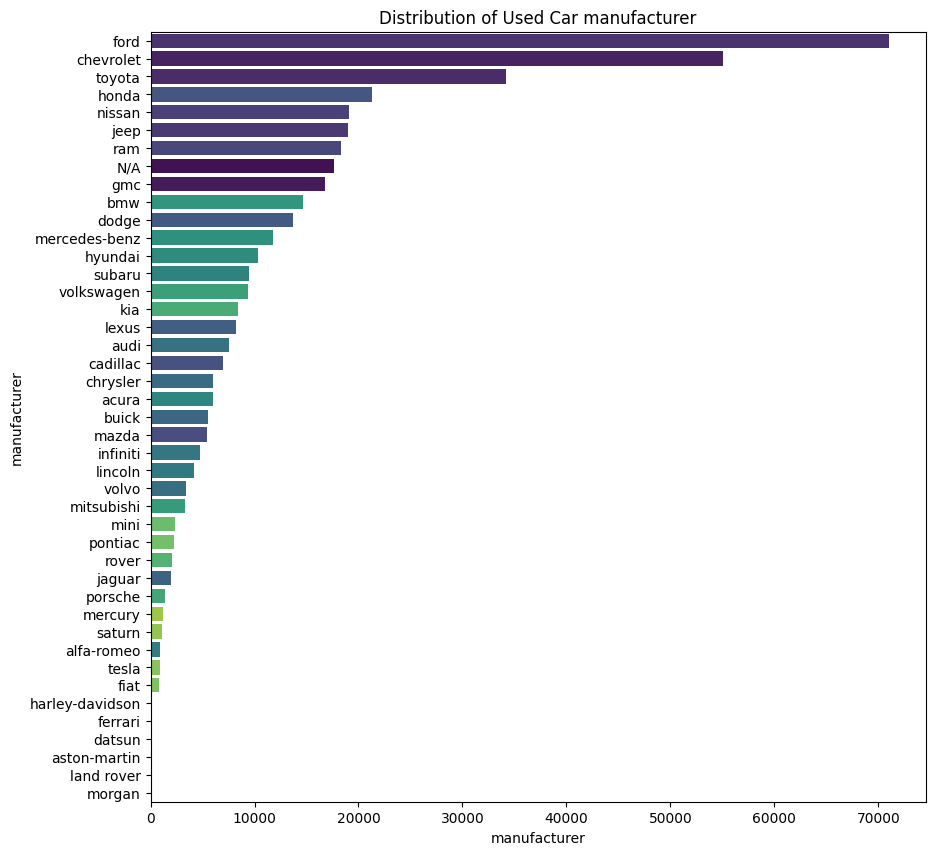

In [9]:
# show the distribution of the manufacturer
show_countplot(df, 'manufacturer')

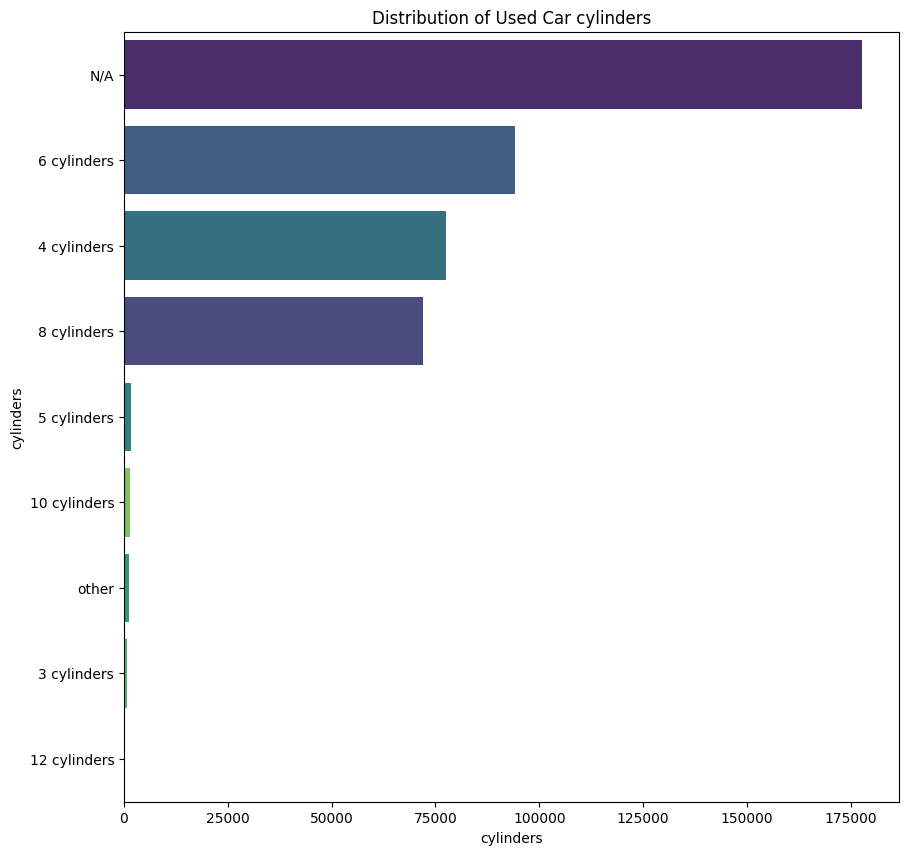

In [10]:
# show the distribution of the cylinders
show_countplot(df, 'cylinders')

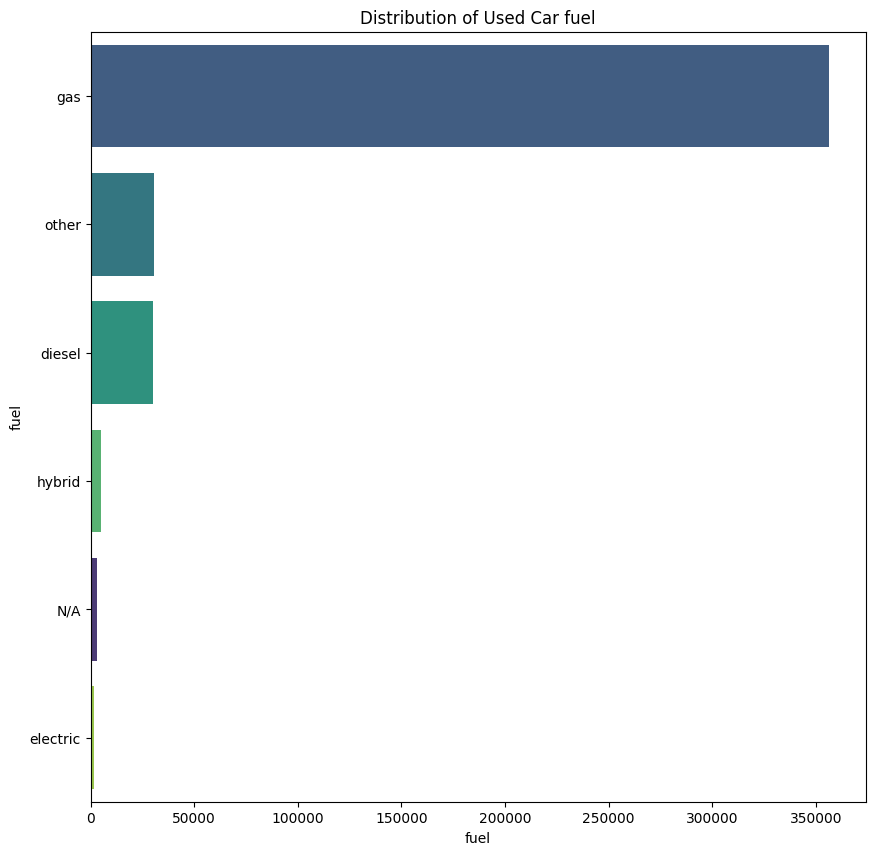

In [11]:
# show the distribution of the fuel
show_countplot(df, 'fuel')

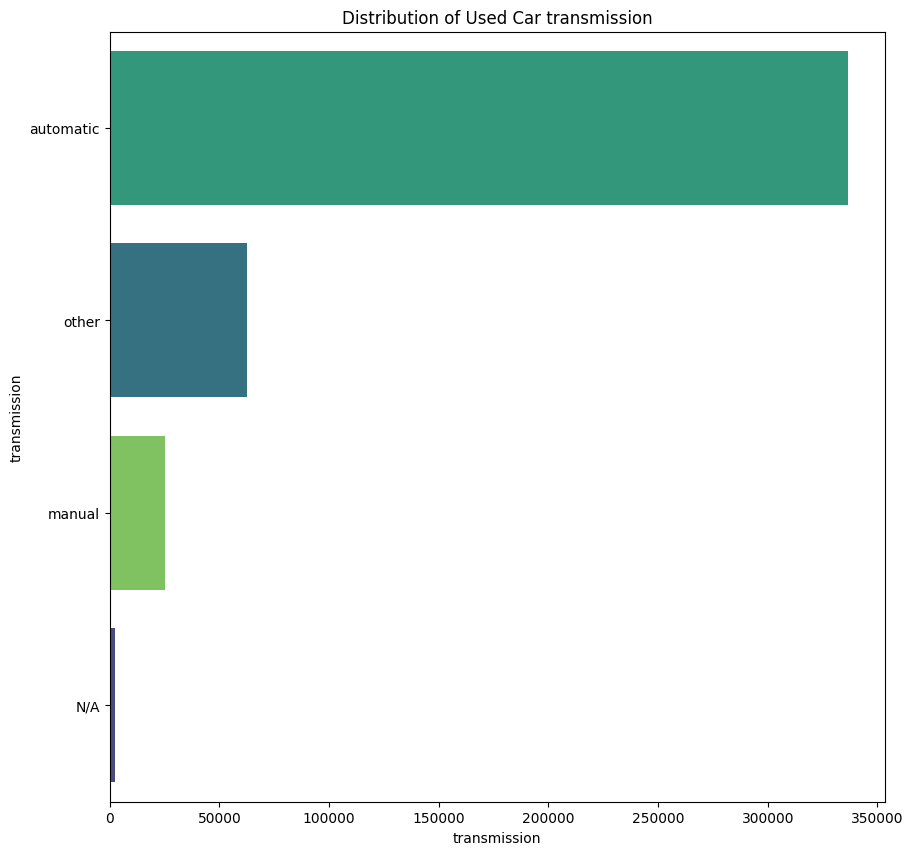

In [12]:
# show the distribution of the transmission
show_countplot(df, 'transmission')

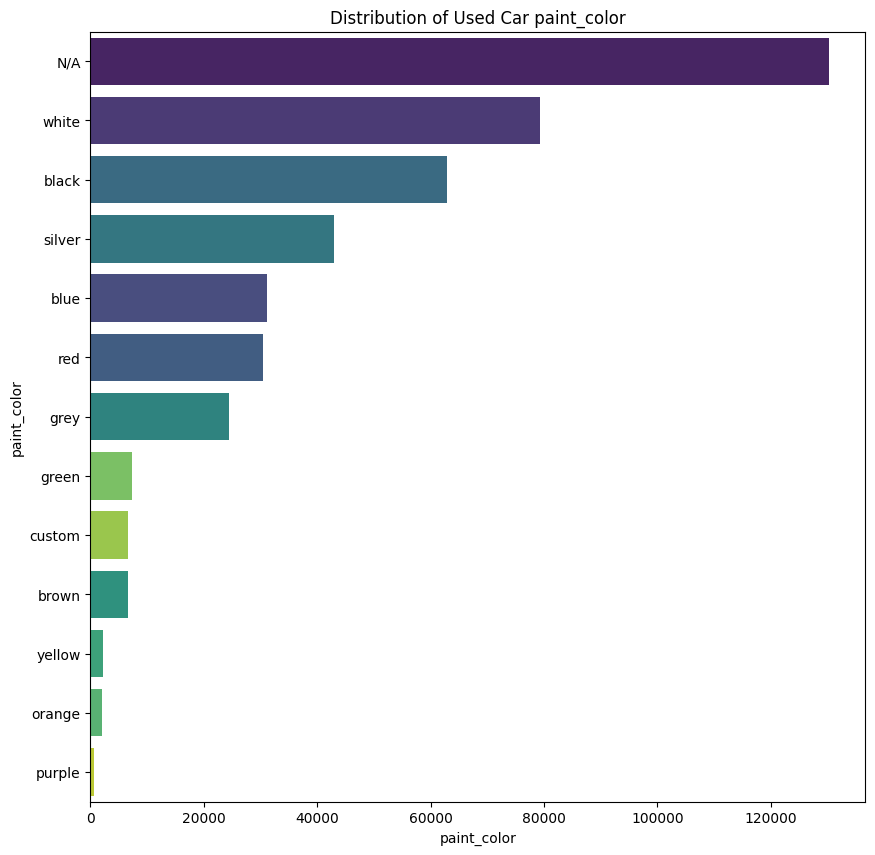

In [14]:
# show the distribution of the Paint Color
show_countplot(df, 'paint_color')

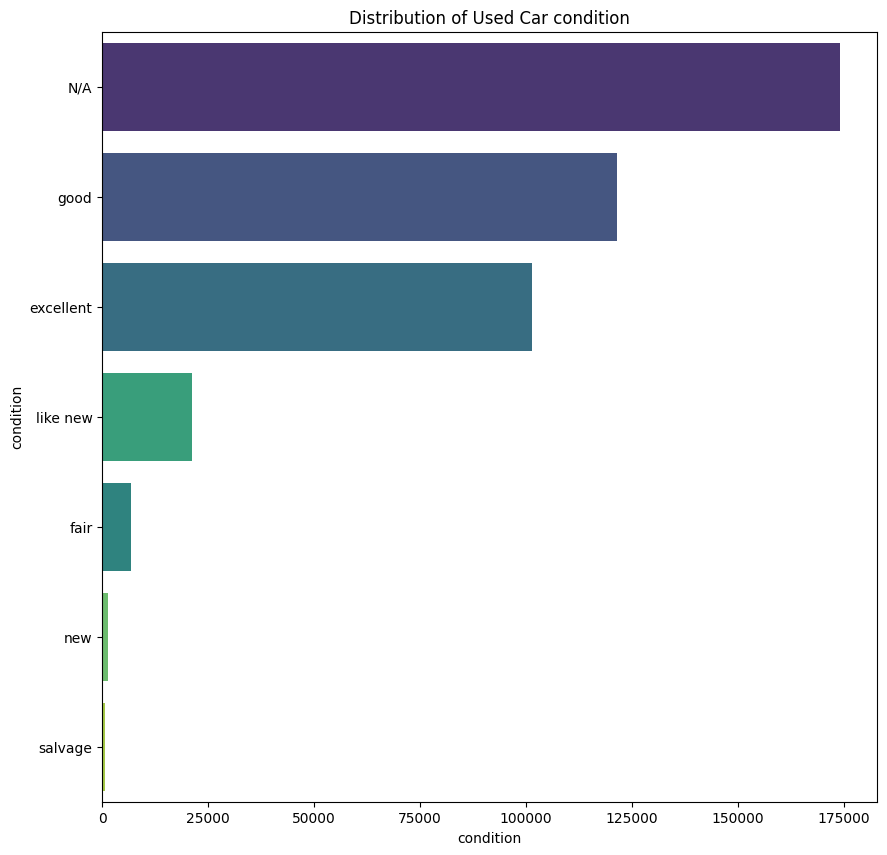

In [15]:
# show the distribution of the condition
show_countplot(df, 'condition')

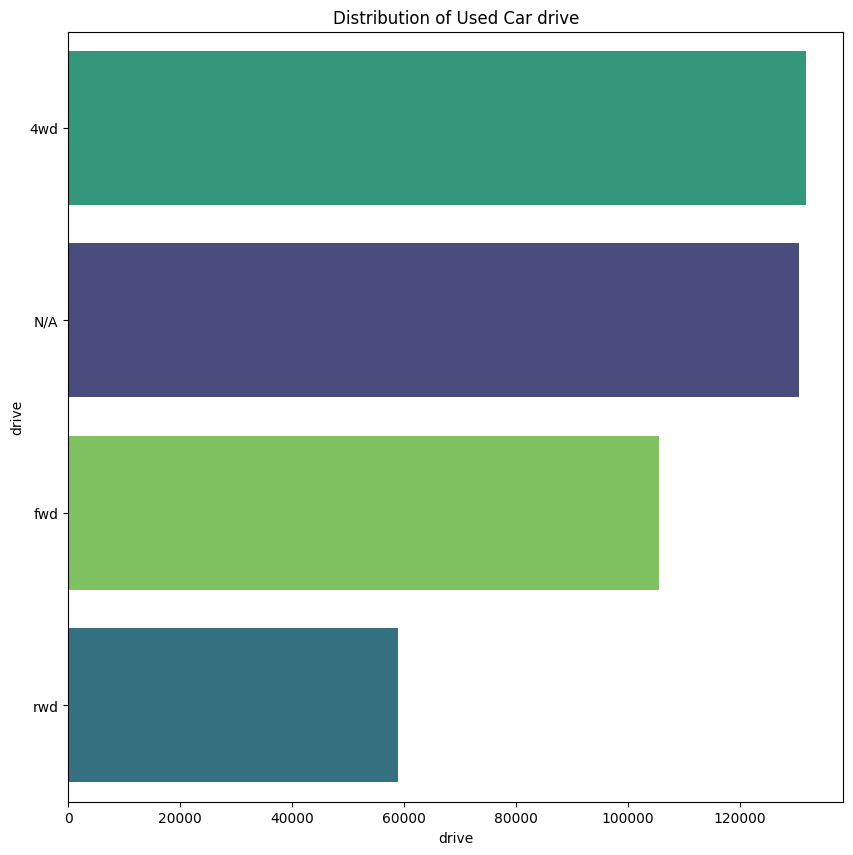

In [16]:
# show the distribution of the drive 
show_countplot(df, 'drive')